# Module 2, Lesson 3: Simple Time-Series Forecasting

## Forecasting Water Demand in DMA1

In this notebook, we will use hourly water demand data from DMA1 to forecast demand for the next 24 hours.

We will use:

- **Historical data:** one month of hourly demand observations
- **Forecast horizon:** 24 hours
- **Temporal resolution:** 1 hour

We will compare four simple forecasting methods:

- **Mean method**
- **Naïve method**
- **Seasonal naïve method**
- **Drift method**

These methods are intentionally simple. They provide useful **benchmarks** that more advanced forecasting methods should improve upon.

The methods follow the examples in *Forecasting: Principles and Practice*:

https://otexts.com/fpp3/simple-methods.html

## <font color="blue"><b>PART 1: LOAD THE DATA</b></font>

We will use the same folder structure and dataset as in the previous notebook.

In [1]:
# Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import packages

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Define course folders

course_folder = '/content/drive/MyDrive/CE374U2_Fall2026'
data_folder = os.path.join(course_folder, 'data')
figures_folder = os.path.join(course_folder, 'figures')

In [4]:
# Define the path to the data file

file_name = '02_01_timeseries_basic.csv'
data_file = os.path.join(data_folder, file_name)

In [5]:
# Load the CSV file

df = pd.read_csv(data_file)

df.head()

,Date-time CET-CEST (DD/MM/YYYY HH:mm),DMA 1 (L/s),DMA 2 (L/s)
0,1/1/2021 0:00,NaN,NaN
1,1/1/2021 1:00,NaN,NaN
2,1/1/2021 2:00,NaN,NaN
3,1/1/2021 3:00,NaN,NaN
4,1/1/2021 4:00,NaN,NaN


## <font color="blue"><b>PART 2: PREPARE DMA1</b></font>

We will use the same column names as in the previous notebook and convert the timestamp to a datetime object.

For this forecasting example, we will focus on **January 2023**, which contains a continuous sequence of hourly DMA1 observations.

In [6]:
# Rename columns

df = df.rename(columns={
    'Date-time CET-CEST (DD/MM/YYYY HH:mm)': 'timestamp',
    'DMA 1 (L/s)': 'DMA1',
    'DMA 2 (L/s)': 'DMA2'
})

In [7]:
# Convert timestamp to datetime

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

In [8]:
# Select January 2023 and keep only timestamp and DMA1

df_dma1 = df[
    (df['timestamp'] >= '2023-01-01') &
    (df['timestamp'] < '2023-02-01')
][['timestamp', 'DMA1']].copy()

df_dma1.head()

,timestamp,DMA1
17520,2023-01-01 00:00:00,3.97
17521,2023-01-01 01:00:00,4.51
17522,2023-01-01 02:00:00,4.24
17523,2023-01-01 03:00:00,3.92
17524,2023-01-01 04:00:00,3.91


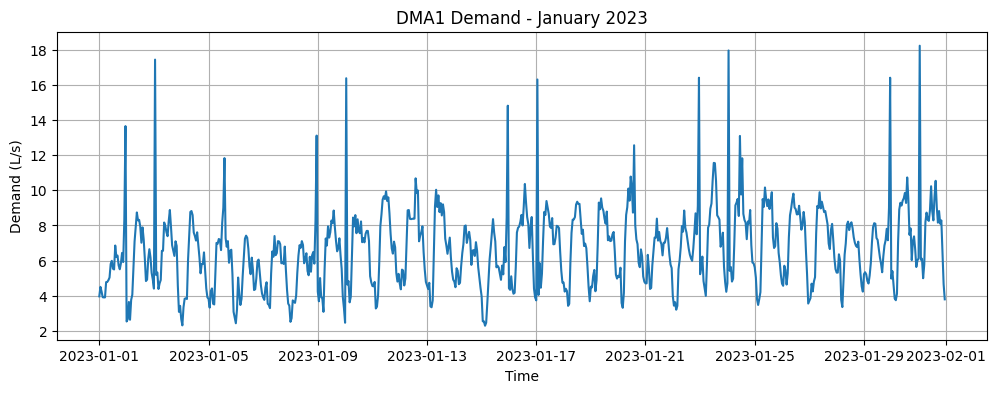

In [9]:
# Plot DMA1 demand

plt.figure(figsize=(12, 4))
plt.plot(df_dma1['timestamp'], df_dma1['DMA1'])

plt.title('DMA1 Demand - January 2023')
plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 3: DEFINE THE FORECASTING PROBLEM</b></font>

We will use the first 30 days of January as historical data and forecast the final day.

### Forecast origin
Midnight at the beginning of January 31.

### Forecast horizon
The next **24 hours**.

### Forecast time step
**1 hour**.

So we need to produce **24 forecast values**.

In [10]:
# Use observations through January 30 to forecast January 31

historical_data = df_dma1[df_dma1['timestamp'] < '2023-01-31']
observed = df_dma1[df_dma1['timestamp'] >= '2023-01-31']

print(f'Training observations: {len(historical_data)}')
print(f'Test observations: {len(observed)}')

Training observations: 720
Test observations: 24


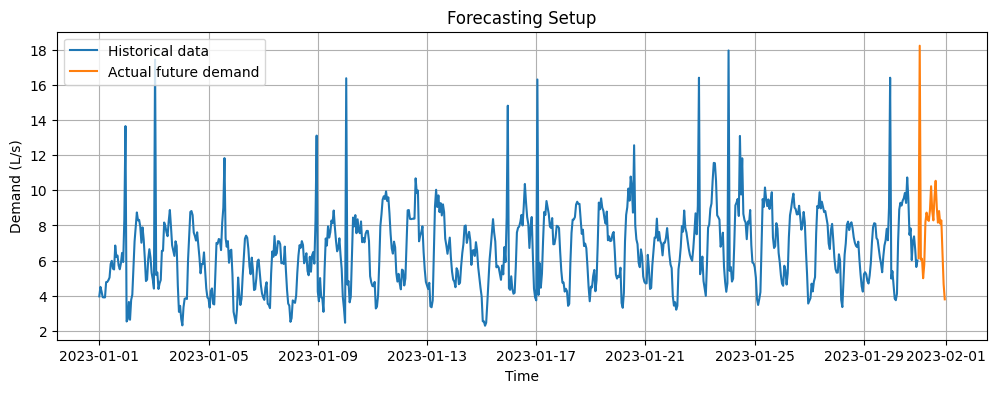

In [11]:
# Plot the training and test periods

plt.figure(figsize=(12, 4))

plt.plot(historical_data['timestamp'], historical_data['DMA1'], label='Historical data')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual future demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Forecasting Setup')
plt.legend()
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 4: MEAN METHOD</b></font>

The **mean method** predicts every future value using the average of all historical observations.

$$ \hat{y}_{T+h|T} = \bar{y} = \frac{y_1 + \cdots + y_T}{T} $$

This means that every forecast value is the same.

In [12]:
# Mean forecast

mean_value = historical_data['DMA1'].mean()

print(f'Mean value: {mean_value:.2f}')

forecast_horizon = 24

mean_value = historical_data['DMA1'].mean()
mean_forecast = [mean_value] * forecast_horizon


Mean value: 6.60


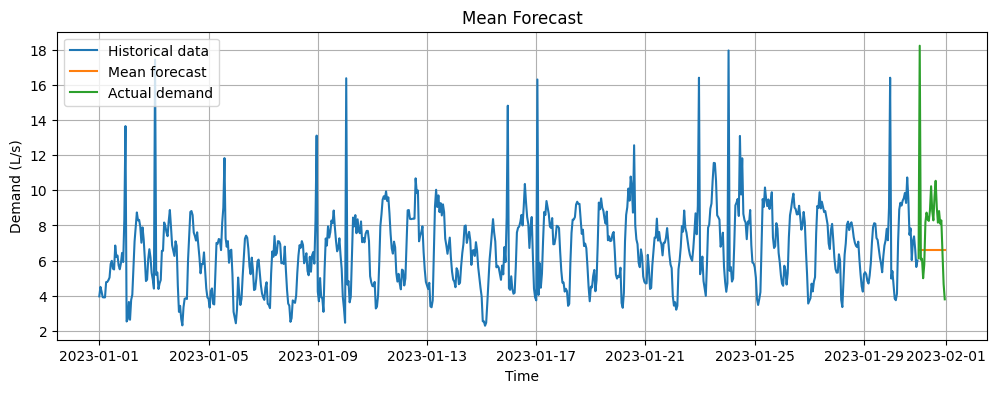

In [13]:
# Plot the mean forecast

plt.figure(figsize=(12, 4))

plt.plot(historical_data['timestamp'], historical_data['DMA1'], label='Historical data')
plt.plot(observed['timestamp'], mean_forecast, label='Mean forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Mean Forecast')
plt.legend()
plt.grid(True)

plt.show()

## Lets zoom in
### Selecting the Historical Data to Display

Python slicing uses the format:

`[start : end]`

For example:

`[-72:]`

means:

- `-72` starts 72 observations from the end of the data
- leaving the value after `:` empty means continue **until the end**

Therefore, `[-72:]` selects the **last 72 observations**.

Since our data are hourly, the last 72 observations represent the **last 72 hours (3 days)** of historical data.

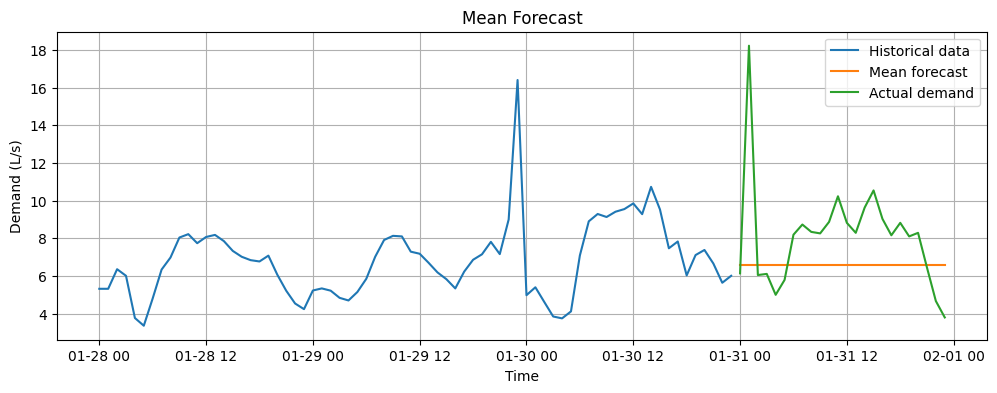

In [14]:
# Plot the mean forecast

plt.figure(figsize=(12, 4))

plot_history = 72

plt.plot(historical_data['timestamp'].iloc[-plot_history:], historical_data['DMA1'].iloc[-plot_history:], label='Historical data')
plt.plot(observed['timestamp'], mean_forecast, label='Mean forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Mean Forecast')
plt.legend()
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 5: NAÏVE METHOD</b></font>

The **naïve method** assumes that all future values will be equal to the **last observed value**.

$$\hat{y}_{T+h|T} = y_T$$

This is one of the simplest possible forecasting methods.

In [15]:
# Naive forecast

last_value = historical_data['DMA1'].iloc[-1]

print(f'Last value: {last_value:.2f}')

naive_forecast = [last_value] * forecast_horizon

Last value: 6.01


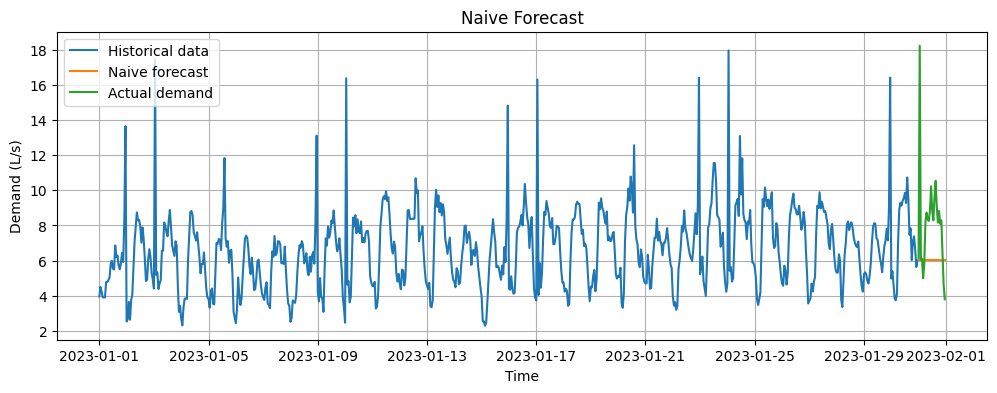

In [16]:
# Plot the naive forecast

plt.figure(figsize=(12, 4))

plt.plot(historical_data['timestamp'], historical_data['DMA1'], label='Historical data')
plt.plot(observed['timestamp'], naive_forecast, label='Naive forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Naive Forecast')
plt.legend()
plt.grid(True)

plt.show()

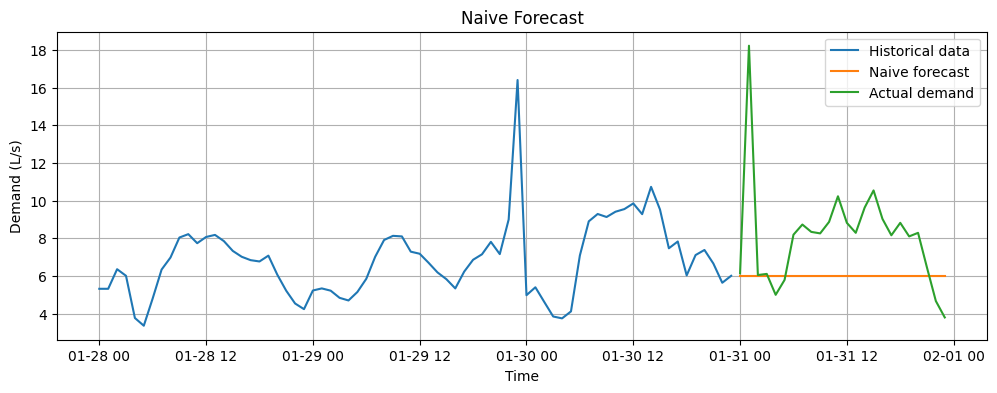

In [17]:
# Plot the naive forecast

plt.figure(figsize=(12, 4))

plot_history = 72

plt.plot(historical_data['timestamp'].iloc[-plot_history:], historical_data['DMA1'].iloc[-plot_history:], label='Historical data')
plt.plot(observed['timestamp'], naive_forecast, label='Naive forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Naive Forecast')
plt.legend()
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 6: SEASONAL NAÏVE METHOD</b></font>

Water demand often follows a strong daily pattern.

For hourly data, a **seasonal naïve forecast** can use the demand observed at the **same hour on the previous day**.

For example:

- Tomorrow at 8 AM → use today's demand at 8 AM
- Tomorrow at 5 PM → use today's demand at 5 PM

Because our forecast horizon is 24 hours, we can simply use the final 24 observations in the training data.

### Selecting the Previous Seasonal Cycle

The seasonal naïve method uses the observations from the **previous seasonal cycle** as the forecast.

$$ \hat{y}_{T+h|T} = y_{T+h-m(k+1)}$$

For hourly data with a daily cycle:

`season_length = 24`

The syntax:

`train['DMA1'].iloc[-season_length:].values`

selects the last 24 demand observations:

- `.iloc` selects observations by their **position**
- `-season_length` starts 24 observations from the end
- `:` means continue from that position to the end
- `.values` returns only the numerical values as a NumPy array

Therefore, the last 24 hourly observations are used as the forecast for the next 24 hours.


In [18]:
# Seasonal naive forecast

season_length = 24

seasonal_naive_forecast = historical_data['DMA1'].iloc[-season_length:].values

seasonal_naive_forecast

array([ 4.98,  5.4 ,  4.62,  3.85,  3.75,  4.12,  7.09,  8.9 ,  9.29,
        9.13,  9.41,  9.55,  9.85,  9.28, 10.73,  9.53,  7.47,  7.83,
        6.03,  7.11,  7.38,  6.66,  5.64,  6.01])

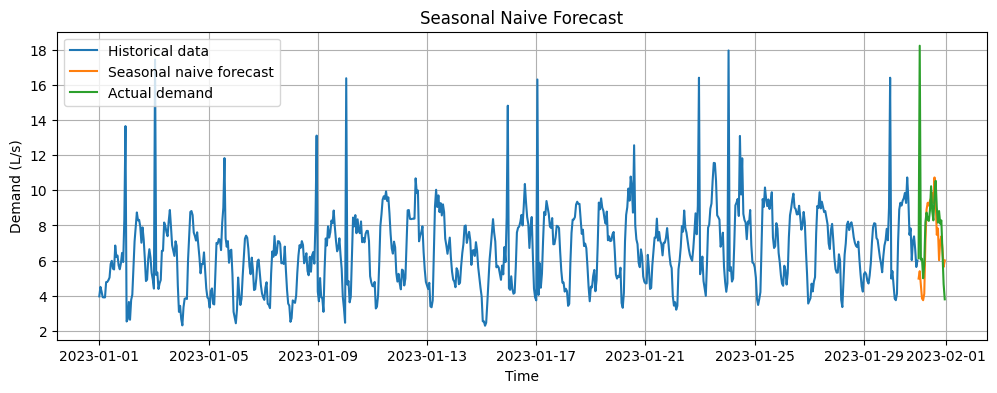

In [19]:
# Plot the seasonal naive forecast

plt.figure(figsize=(12, 4))

plt.plot(historical_data['timestamp'], historical_data['DMA1'], label='Historical data')
plt.plot(observed['timestamp'], seasonal_naive_forecast, label='Seasonal naive forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Seasonal Naive Forecast')
plt.legend()
plt.grid(True)

plt.show()

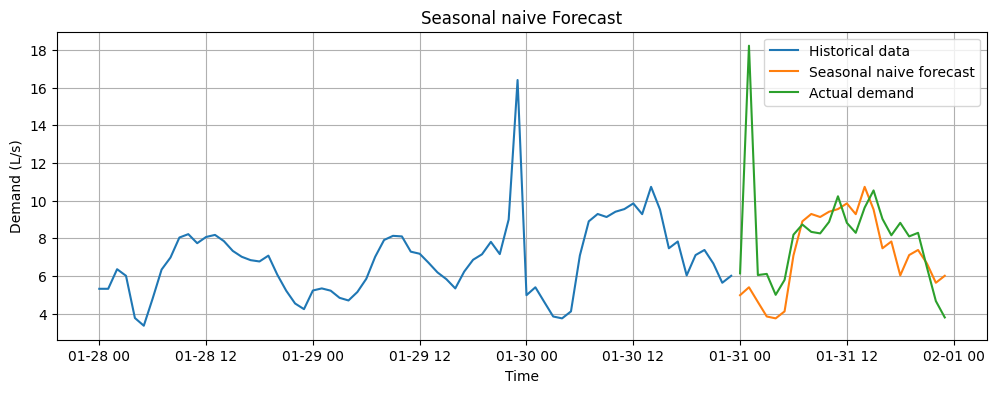

In [20]:
# Plot the seasonal naive forecast

plt.figure(figsize=(12, 4))

plot_history = 72

plt.plot(historical_data['timestamp'].iloc[-plot_history:], historical_data['DMA1'].iloc[-plot_history:], label='Historical data')
plt.plot(observed['timestamp'], seasonal_naive_forecast, label='Seasonal naive forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Seasonal naive Forecast')
plt.legend()
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 7: DRIFT METHOD</b></font>

The **drift method** extends the naïve method by allowing the forecast to increase or decrease over time.

The average change per time step is calculated from the first and last historical observations:

$$
\text{drift} = \frac{y_T-y_1}{T-1}
$$

The forecast then continues this average trend into the future:

$$
\hat{y}_{T+h|T}
=
y_T + h\left(\frac{y_T-y_1}{T-1}\right)
$$

This is equivalent to drawing a straight line between the first and last observations and extending it forward.


In [21]:
# Calculate the average drift per hour

first_value = historical_data['DMA1'].iloc[0]
last_value = historical_data['DMA1'].iloc[-1]

drift = (last_value - first_value) / (len(historical_data) - 1)

print(f'Drift per hour: {drift:.4f} L/s')

Drift per hour: 0.0028 L/s


For the drift method, the forecast depends on how many time steps ahead we are forecasting, where $h$ is the **forecast horizon**.

Because our data are hourly and we want to forecast the next 24 hours:

- $h=1$ is 1 hour ahead
- $h=2$ is 2 hours ahead
- ...
- $h=24$ is 24 hours ahead

We use `np.arange(1, 25)` to create these 24 forecast horizons.

The drift forecast is then calculated for all 24 horizons at once.

In [22]:
# Forecast horizon: 1 to 24 hours ahead
h = np.arange(1, 25)

# Drift forecast
drift_forecast = last_value + h * drift

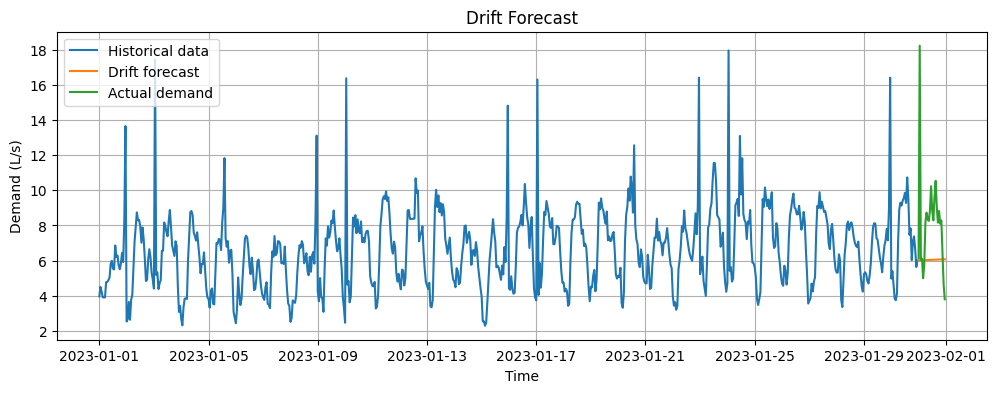

In [23]:
# Plot the drift forecast

plt.figure(figsize=(12, 4))

plt.plot(historical_data['timestamp'], historical_data['DMA1'], label='Historical data')
plt.plot(observed['timestamp'], drift_forecast, label='Drift forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Drift Forecast')
plt.legend()
plt.grid(True)

plt.show()

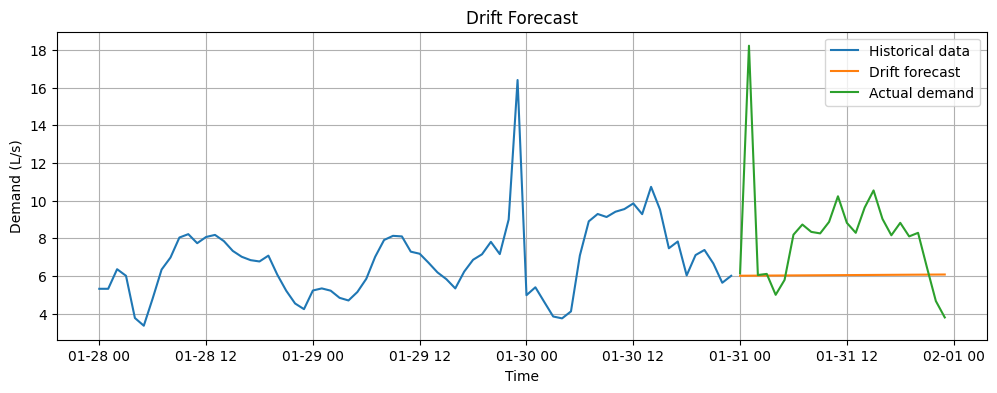

In [24]:
# Plot the drift forecast

plt.figure(figsize=(12, 4))

plot_history = 72

plt.plot(historical_data['timestamp'].iloc[-plot_history:], historical_data['DMA1'].iloc[-plot_history:], label='Historical data')
plt.plot(observed['timestamp'], drift_forecast, label='Drift forecast')
plt.plot(observed['timestamp'], observed['DMA1'], label='Actual demand')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Drift Forecast')
plt.legend()
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 8: COMPARE THE FOUR FORECASTS</b></font>

Now we can place all four forecasts on the same figure.

Ask:

- Which method captures the daily pattern?
- Which methods produce a constant forecast?
- Which method includes a long-term trend?
- Which forecast looks most similar to the actual demand?

In [25]:
# Create a DataFrame with the forecasts

forecast = observed[['timestamp', 'DMA1']]

forecast['Mean'] = mean_forecast
forecast['Naive'] = naive_forecast
forecast['Seasonal naive'] = seasonal_naive_forecast
forecast['Drift'] = drift_forecast

forecast.head()

,timestamp,DMA1,Mean,Naive,Seasonal naive,Drift
18240,2023-01-31 00:00:00,6.14,6.604361,6.01,4.98,6.012837
18241,2023-01-31 01:00:00,18.22,6.604361,6.01,5.40,6.015675
18242,2023-01-31 02:00:00,6.05,6.604361,6.01,4.62,6.018512
18243,2023-01-31 03:00:00,6.11,6.604361,6.01,3.85,6.021349
18244,2023-01-31 04:00:00,5.00,6.604361,6.01,3.75,6.024186


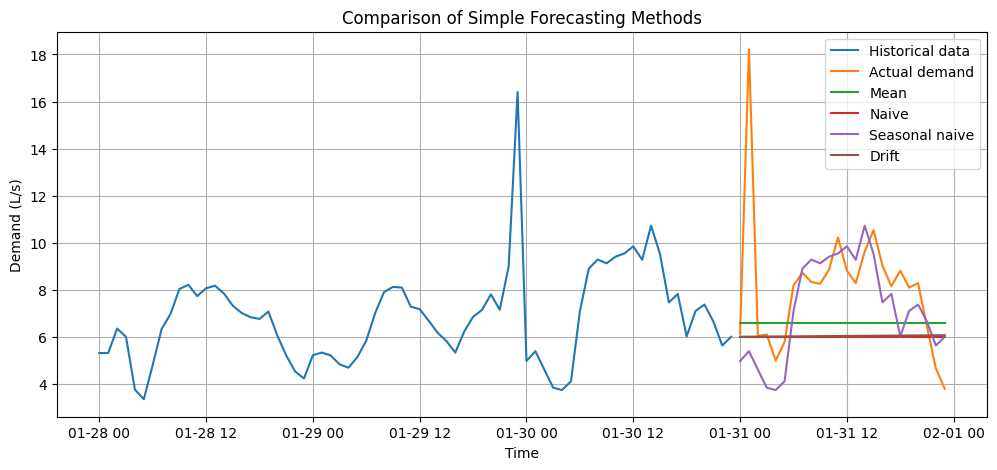

In [26]:
# Plot all four forecasts

plt.figure(figsize=(12, 5))
plot_history = 72

plt.plot(historical_data['timestamp'].iloc[-plot_history:], historical_data['DMA1'].iloc[-plot_history:], label='Historical data')
plt.plot(forecast['timestamp'], forecast['DMA1'], label='Actual demand')

plt.plot(forecast['timestamp'], forecast['Mean'], label='Mean')
plt.plot(forecast['timestamp'], forecast['Naive'], label='Naive')
plt.plot(forecast['timestamp'], forecast['Seasonal naive'], label='Seasonal naive')
plt.plot(forecast['timestamp'], forecast['Drift'], label='Drift')

plt.xlabel('Time')
plt.ylabel('Demand (L/s)')
plt.title('Comparison of Simple Forecasting Methods')
plt.legend()
plt.grid(True)

plt.show()

## <font color="blue"><b>PART 9: FORECAST ACCURACY</b></font>

A forecast should be evaluated using observations that were **not used to create the forecast**.

The **forecast error** is the difference between the observed value and the forecast:

$$
e_t = y_t - \hat{y}_t
$$

where:

- $y_t$ is the observed value
- $\hat{y}_t$ is the forecast value
- $e_t$ is the forecast error

Three common measures can be used to summarize forecast accuracy.

### Mean Absolute Error (MAE)

MAE is the average magnitude of the forecast errors:

$$
\text{MAE} = \frac{1}{n}\sum_{t=1}^{n}|e_t|
$$

MAE has the **same units as the original data**.

### Root Mean Squared Error (RMSE)

RMSE squares the errors before averaging, giving more weight to large errors:

$$
\text{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{t=1}^{n}e_t^2
}
$$

RMSE also has the **same units as the original data**.

### Mean Absolute Percentage Error (MAPE)

MAPE expresses the forecast error relative to the observed value:

$$
\text{MAPE}
=
\frac{100}{n}
\sum_{t=1}^{n}
\left|
\frac{e_t}{y_t}
\right|
$$

MAPE is expressed as a **percentage**, making it easier to interpret and compare errors across time series with different scales.

**Important:** MAPE is undefined when an observed value is zero and can become very large when observed values are close to zero.

For all three measures, **smaller values indicate a more accurate forecast**.

In [27]:
# Observed demand
actual = observed['DMA1'].values

# Mean method
mean_errors = actual - mean_forecast

mean_mae = np.mean(np.abs(mean_errors))
mean_rmse = np.sqrt(np.mean(mean_errors ** 2))
mean_mape = np.mean(np.abs(mean_errors / actual)) * 100

# Naive method
naive_errors = actual - naive_forecast

naive_mae = np.mean(np.abs(naive_errors))
naive_rmse = np.sqrt(np.mean(naive_errors ** 2))
naive_mape = np.mean(np.abs(naive_errors / actual)) * 100

# Seasonal naive method
seasonal_naive_errors = actual - seasonal_naive_forecast
seasonal_naive_mae = np.mean(np.abs(seasonal_naive_errors))
seasonal_naive_rmse = np.sqrt(np.mean(seasonal_naive_errors ** 2))
seasonal_naive_mape = np.mean(np.abs(seasonal_naive_errors / actual)) * 100

# Drift method
drift_errors = actual - drift_forecast

drift_mae = np.mean(np.abs(drift_errors))
drift_rmse = np.sqrt(np.mean(drift_errors ** 2))
drift_mape = np.mean(np.abs(drift_errors / actual)) * 100

In [28]:
results = pd.DataFrame({
    'Method': ['Mean', 'Naive', 'Seasonal naive', 'Drift'],
    'MAE': [mean_mae, naive_mae, seasonal_naive_mae, drift_mae],
    'RMSE': [mean_rmse, naive_rmse, seasonal_naive_rmse, drift_rmse],
    'MAPE (%)': [mean_mape, naive_mape, seasonal_naive_mape, drift_mape]
})

results

,Method,MAE,RMSE,MAPE (%)
0,Mean,2.236463,3.111186,25.914192
1,Naive,2.493750,3.437598,27.518278
2,Seasonal naive,1.625000,2.909247,19.030047
3,Drift,2.471998,3.419374,27.334869


## <font color="blue"><b>PART 10: PRACTICE EXERCISES</b></font>

## 🧩 Exercise 1: Change the forecast horizon

Repeat the analysis using a **48-hour forecast horizon**.

Think about:

1. How many forecast values are needed?
2. What changes for the mean forecast?
3. What changes for the naïve forecast?
4. How would you construct the seasonal naïve forecast?
5. How does forecast accuracy compare with the 24-hour forecast?

## 🧩 Exercise 2: Apply the Methods to a Different Time Period

Choose a **different month** from the DMA1 dataset.

Use the first part of the month as historical data and forecast demand for the **next 3 days (72 hours)**.

1. Create forecasts using the four methods:
   - Mean
   - Naïve
   - Seasonal naïve
   - Drift
2. Plot the observed demand and the four forecasts.
3. Calculate MAE and RMSE for each method.
4. Which method performs best?
5. Does the best-performing method change compared with our original example?

## 🧩 Exercise 3: Reflection

1. Which of the four methods performed best for DMA1?
2. Why might the seasonal naïve method work well for hourly water demand?
3. Which method accounts for long-term trend?
4. Which methods ignore the daily demand pattern?
5. Why are simple forecasting methods useful even when more advanced methods are available?

## <font color="blue"><b>KEY TAKEAWAYS</b></font>

You can now:

✅ Define a forecast horizon and forecast time step  
✅ Create a mean forecast  
✅ Create a naïve forecast  
✅ Create a seasonal naïve forecast  
✅ Create a drift forecast  
✅ Compare forecasts with observed values  
✅ Evaluate simple forecasting methods using MAE and RMSE  

These simple methods provide important **benchmarks** for evaluating more advanced forecasting approaches.